In [ ]:
print(data['y'].unique())
print(data['y'].value_counts())


[0 1]
y
0    2359
1     668
Name: count, dtype: int64


In [ ]:
import pandas as pd

# Load the dataset
file_path = 'credit_card_default.arff'
column_names = [
    'id', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9',
    'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16' , 'X17' , 'X18' ,
    'X19', 'X20', 'X21' , 'X22' , 'X23' , 'y'
]
data = pd.read_csv('credit_card_default.arff', header=None, names=column_names, na_values='?')

# Display basic info
print(data.head())
print(data.info())


                                         id   X1  X2  X3  X4  X5  X6  X7  X8  \
0  @RELATION default-of-credit-card-clients  NaN NaN NaN NaN NaN NaN NaN NaN   
1                        @ATTRIBUTE id REAL  NaN NaN NaN NaN NaN NaN NaN NaN   
2                        @ATTRIBUTE x1 REAL  NaN NaN NaN NaN NaN NaN NaN NaN   
3                        @ATTRIBUTE x2 REAL  NaN NaN NaN NaN NaN NaN NaN NaN   
4                        @ATTRIBUTE x3 REAL  NaN NaN NaN NaN NaN NaN NaN NaN   

   X9  ...  X15  X16  X17  X18  X19  X20  X21  X22  X23   y  
0 NaN  ...  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN NaN  
1 NaN  ...  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN NaN  
2 NaN  ...  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN NaN  
3 NaN  ...  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN NaN  
4 NaN  ...  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN NaN  

[5 rows x 25 columns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3027 entries, 0 to 3026
Data columns (total 25 columns):
 #   Column  Non-

In [ ]:
from sklearn.impute import SimpleImputer

# Separate numerical and categorical columns
numerical_cols = data.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = data.select_dtypes(include=['object']).columns

# Impute missing values
num_imputer = SimpleImputer(strategy='mean')
cat_imputer = SimpleImputer(strategy='most_frequent')

data[numerical_cols] = num_imputer.fit_transform(data[numerical_cols])
data[categorical_cols] = cat_imputer.fit_transform(data[categorical_cols])

# Confirm no missing values
print(data.isnull().sum())


id     0
X1     0
X2     0
X3     0
X4     0
X5     0
X6     0
X7     0
X8     0
X9     0
X10    0
X11    0
X12    0
X13    0
X14    0
X15    0
X16    0
X17    0
X18    0
X19    0
X20    0
X21    0
X22    0
X23    0
y      0
dtype: int64


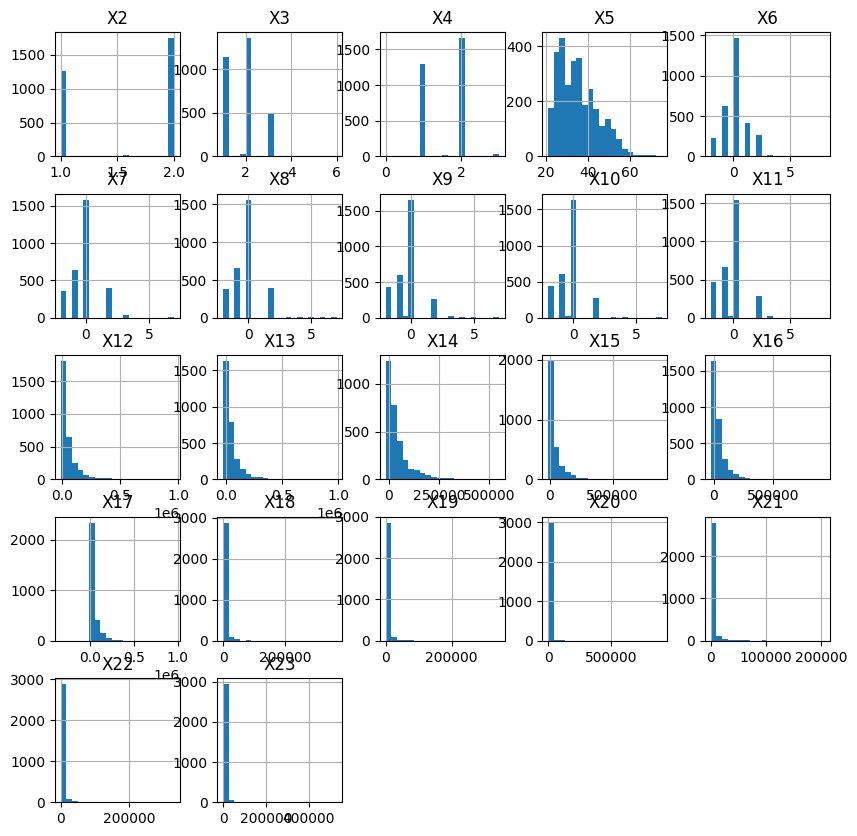

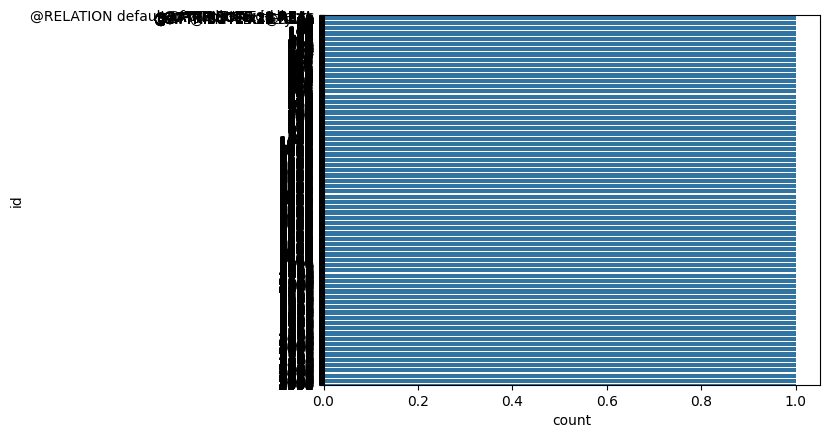

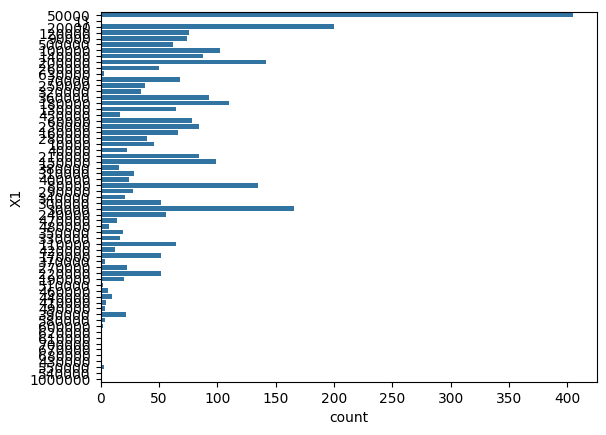

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize numerical data
data[numerical_cols].hist(bins=20, figsize=(10, 10))
plt.show()

# Visualize categorical data
for col in categorical_cols:
    sns.countplot(data[col])
    plt.show()


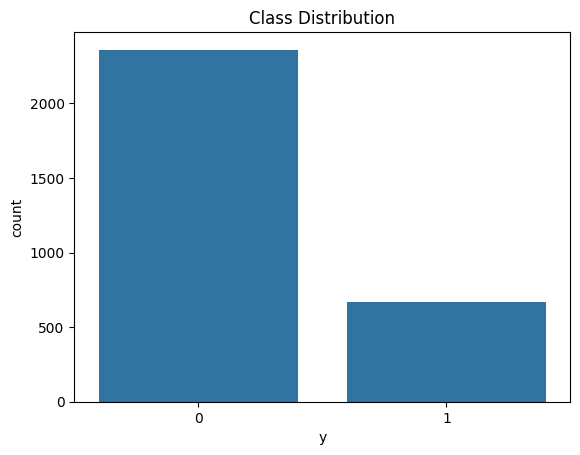

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=data, x='y')
plt.title("Class Distribution")
plt.show()


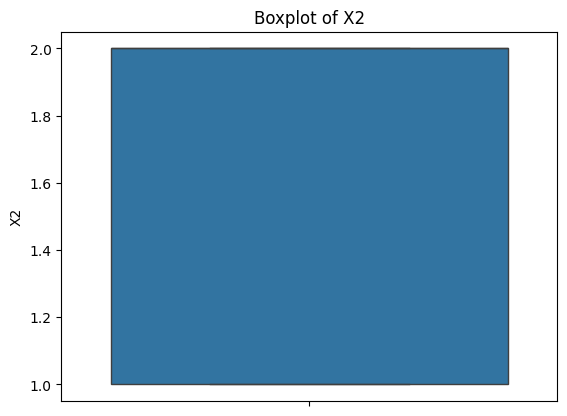

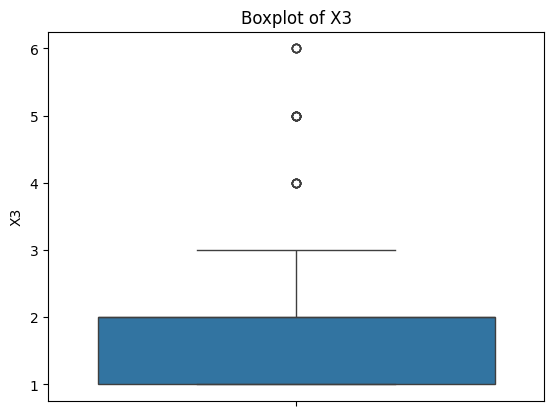

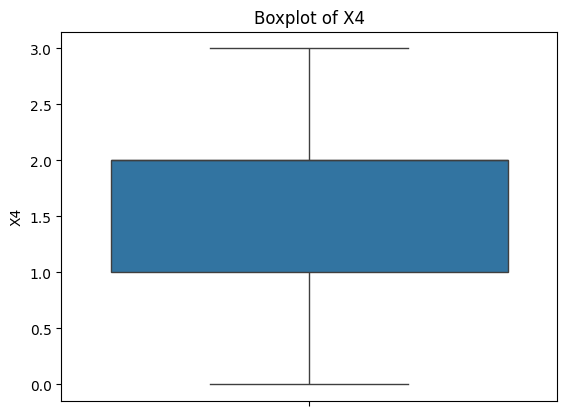

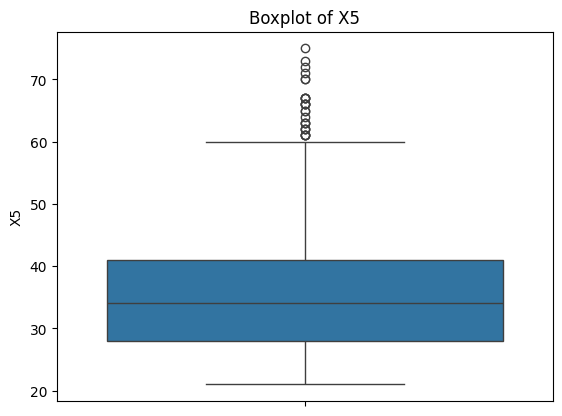

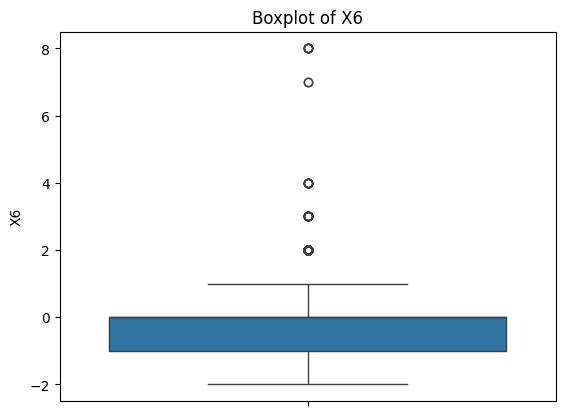

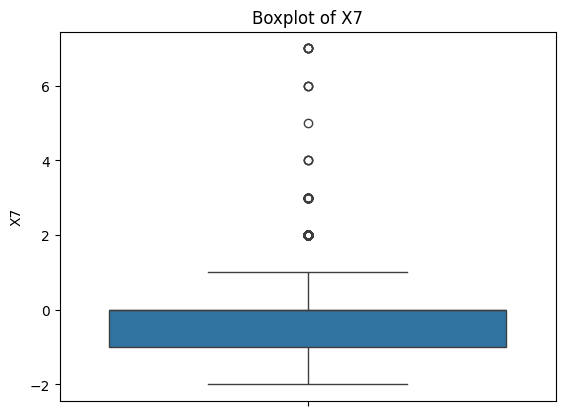

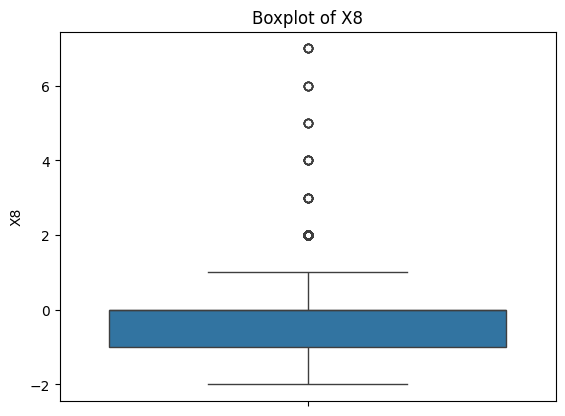

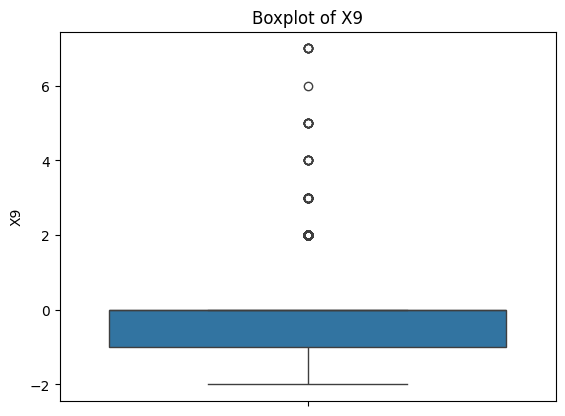

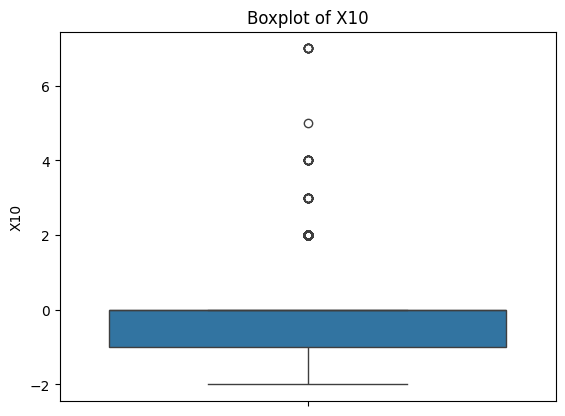

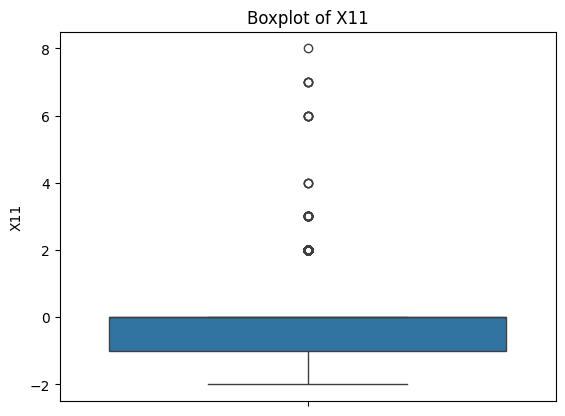

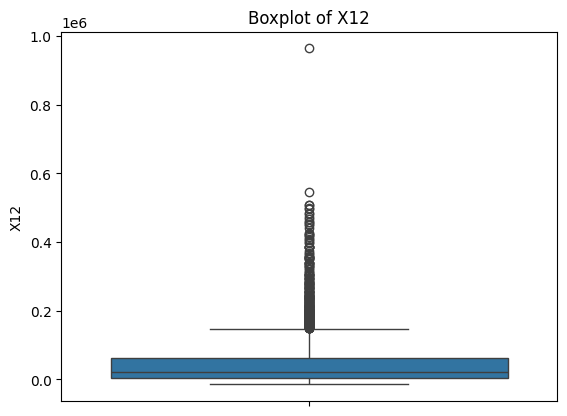

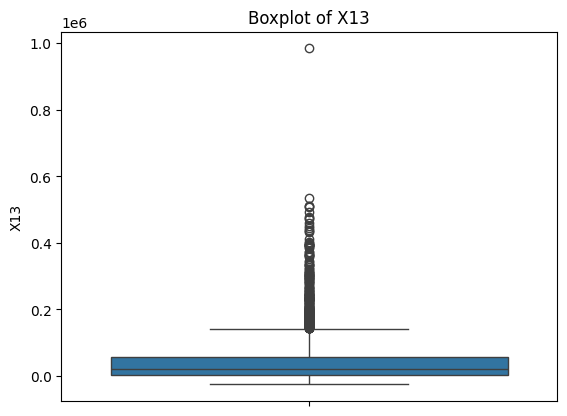

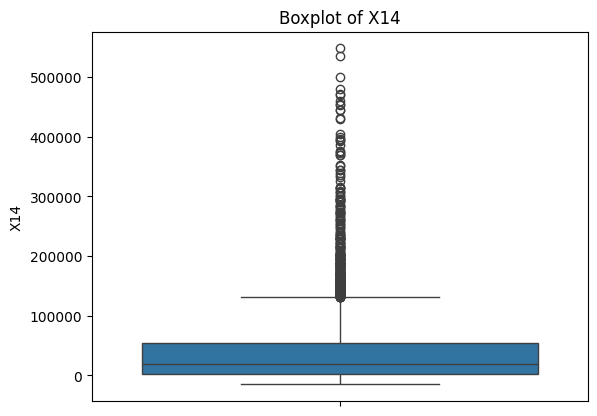

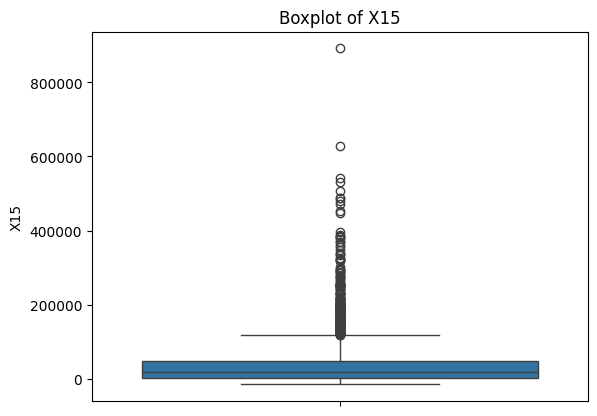

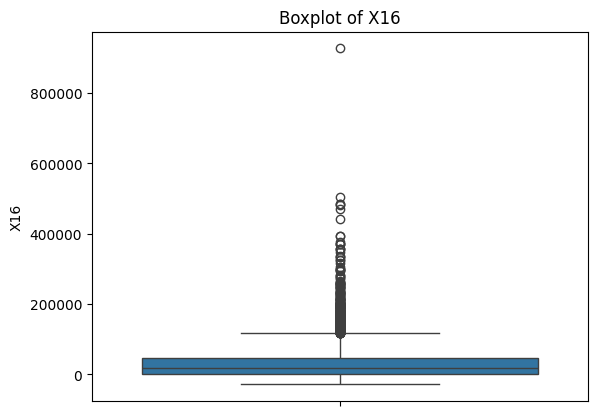

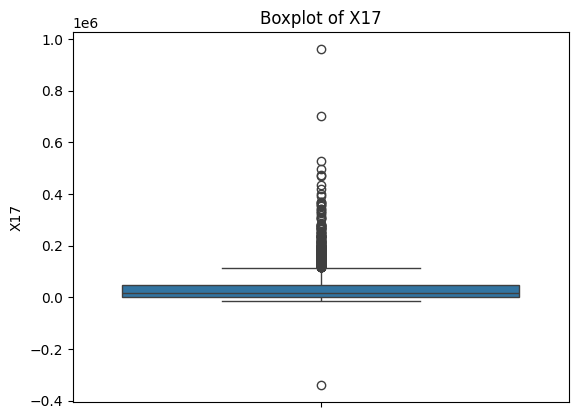

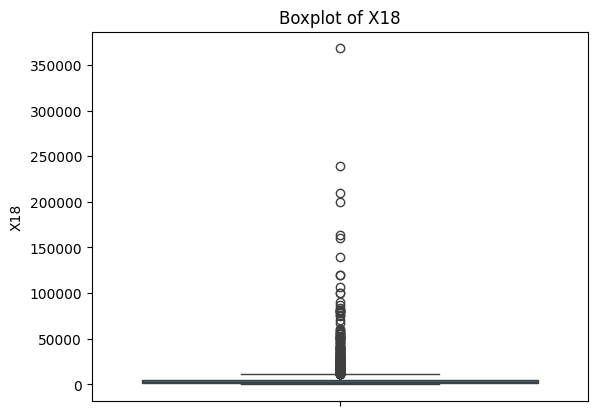

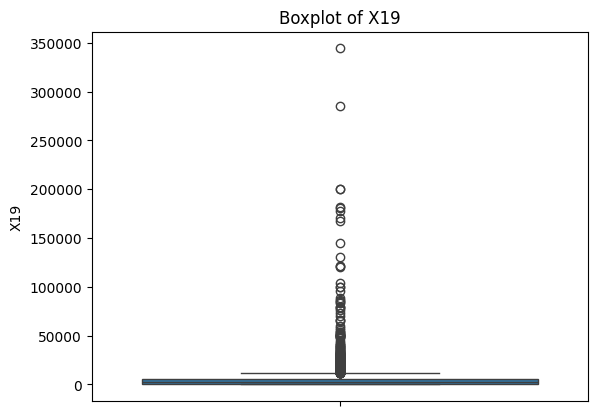

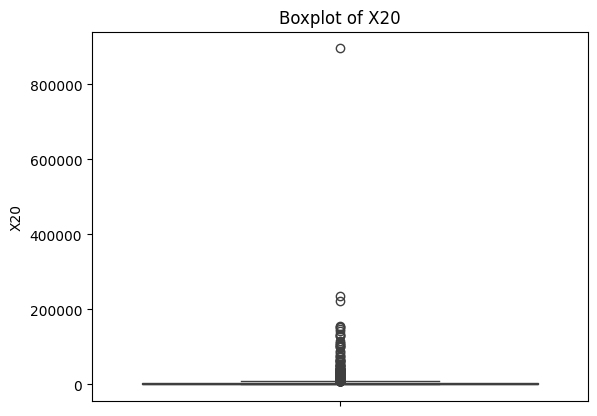

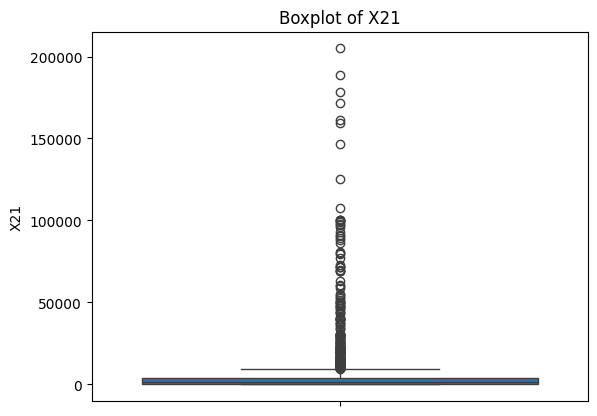

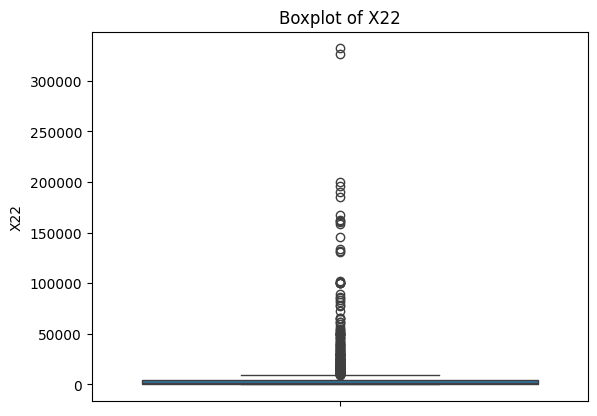

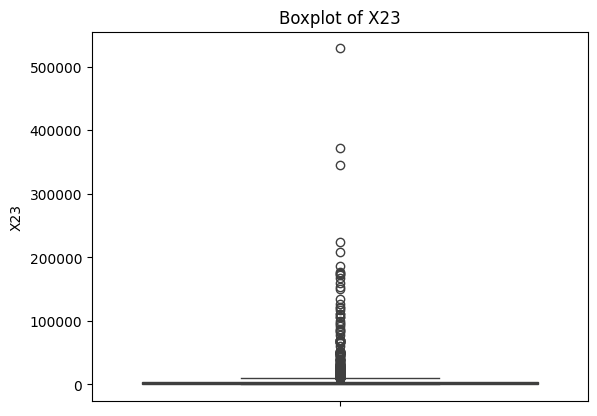

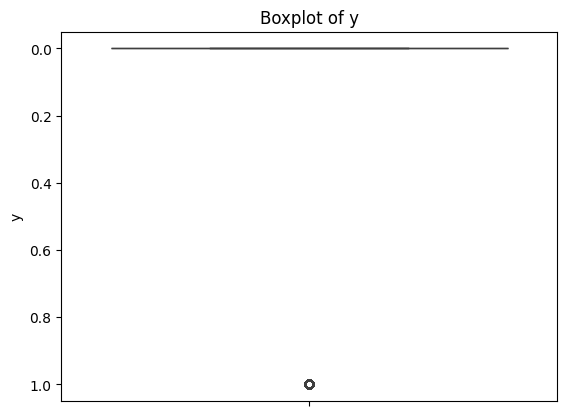

In [ ]:
for col in numerical_cols:
    sns.boxplot(data[col])
    plt.title(f"Boxplot of {col}")
    plt.show()


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Label encode categorical columns
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le


In [ ]:
from sklearn.model_selection import train_test_split

# Features and target
X = data.drop('y', axis=1)
y = data['y']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)


Training set size: (2421, 24)
Test set size: (606, 24)


In [ ]:
from sklearn.preprocessing import StandardScaler

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the logistic regression model again
lr = LogisticRegression(max_iter=10000)
lr.fit(X_train_scaled, y_train)

# Make predictions
lr_predictions = lr.predict(X_test_scaled)
lr_probabilities = lr.predict_proba(X_test_scaled)[:, 1]  # For AUC-ROC


In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Initialize and train the Decision Tree model
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

# Make predictions
dt_predictions = dt.predict(X_test)
dt_probabilities = dt.predict_proba(X_test)[:, 1]


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the Random Forest model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Make predictions
rf_predictions = rf.predict(X_test)
rf_probabilities = rf.predict_proba(X_test)[:, 1]


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

# Initialize and train the Gradient Boosting model
gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)

# Make predictions
gb_predictions = gb.predict(X_test)
gb_probabilities = gb.predict_proba(X_test)[:, 1]


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Function to calculate evaluation metrics
def evaluate_model(y_test, predictions, prob_predictions):
    metrics = {
        'Accuracy': accuracy_score(y_test, predictions),
        'Precision': precision_score(y_test, predictions),
        'Recall': recall_score(y_test, predictions),
        'F1 Score': f1_score(y_test, predictions),
        'AUC-ROC': roc_auc_score(y_test, prob_predictions)
    }
    return metrics

# Evaluate each model
models = {
    "Logistic Regression": (lr_predictions, lr_probabilities),
    "Decision Tree": (dt_predictions, dt_probabilities),
    "Random Forest": (rf_predictions, rf_probabilities),
    "Gradient Boosting": (gb_predictions, gb_probabilities)
}

results = {}
for model_name, (predictions, probabilities) in models.items():
    results[model_name] = evaluate_model(y_test, predictions, probabilities)

# Display results
import pandas as pd
results_df = pd.DataFrame(results).T
print(results_df)


                     Accuracy  Precision    Recall  F1 Score   AUC-ROC
Logistic Regression  0.798680   0.727273  0.175182  0.282353  0.710504
Decision Tree        0.712871   0.356589  0.335766  0.345865  0.579397
Random Forest        0.820132   0.769231  0.291971  0.423280  0.748393
Gradient Boosting    0.816832   0.750000  0.284672  0.412698  0.782197


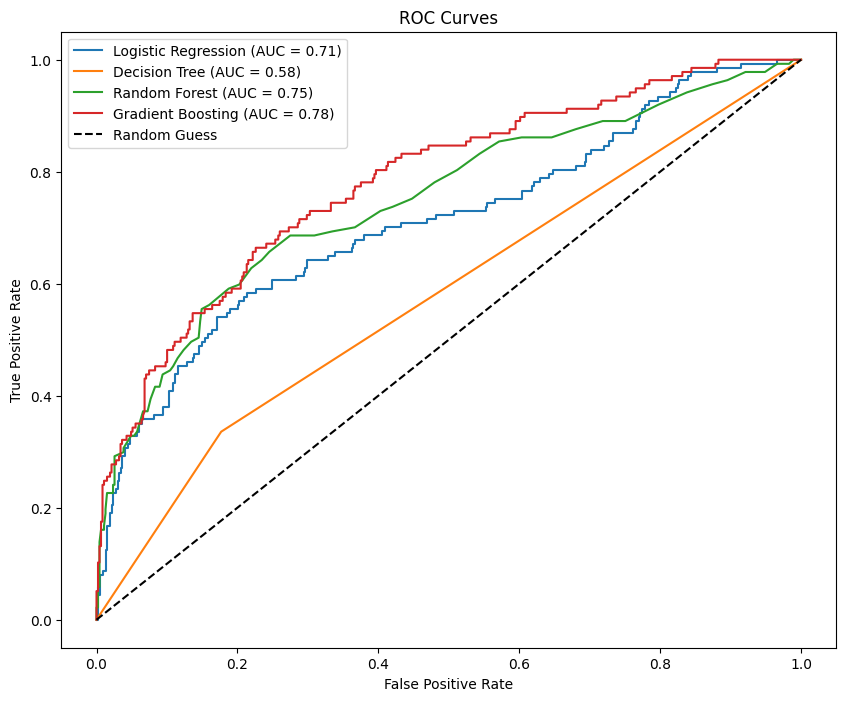

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Plot ROC curve for each model
plt.figure(figsize=(10, 8))
for model_name, (predictions, probabilities) in models.items():
    fpr, tpr, _ = roc_curve(y_test, probabilities)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc_score(y_test, probabilities):.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.show()
